 **Task 1**

In [ ]:
import pandas as pd

In [ ]:
data = """Date,Product,Region,Units_Sold,Unit_Price
2024-01-01,A,North,120,50
2024-01-02,B,South,80,60
2024-01-03,A,East,150,50
2024-01-04,C,West,200,40
2024-01-05,B,North,90,60
2024-01-06,A,South,110,50
2024-01-07,C,East,170,40
2024-01-08,B,West,130,60
2024-01-09,A,North,160,50
2024-01-10,C,South,140,40"""

In [ ]:
from io import StringIO

In [ ]:
df = pd.read_csv(StringIO(data))

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
print("\n2. Date column converted to datetime")
print(f"Date column dtype: {df['Date'].dtype}")


2. Date column converted to datetime
Date column dtype: datetime64[ns]


In [ ]:
df['Total_Sales'] = df['Units_Sold'] * df['Unit_Price']

In [ ]:
print("\n3. Total_Sales column created:")
print(df[['Date', 'Product', 'Units_Sold', 'Unit_Price', 'Total_Sales']])



3. Total_Sales column created:
        Date Product  Units_Sold  Unit_Price  Total_Sales
0 2024-01-01       A         120          50         6000
1 2024-01-02       B          80          60         4800
2 2024-01-03       A         150          50         7500
3 2024-01-04       C         200          40         8000
4 2024-01-05       B          90          60         5400
5 2024-01-06       A         110          50         5500
6 2024-01-07       C         170          40         6800
7 2024-01-08       B         130          60         7800
8 2024-01-09       A         160          50         8000
9 2024-01-10       C         140          40         5600


 **Task 2**

In [ ]:
units_sold_array = df['Units_Sold'].to_numpy()
print("\n4. Units_Sold converted to NumPy array:")
print(f"Array: {units_sold_array}")



4. Units_Sold converted to NumPy array:
Array: [120  80 150 200  90 110 170 130 160 140]


In [ ]:
import numpy as np

In [ ]:
mean_units = np.mean(units_sold_array)
max_units = np.max(units_sold_array)
std_units = np.std(units_sold_array)

In [ ]:
print("\n5. Statistics:")
print(f"   Mean units sold: {mean_units:.2f}")
print(f"   Maximum units sold: {max_units}")
print(f"   Standard deviation: {std_units:.2f}")


5. Statistics:
   Mean units sold: 135.00
   Maximum units sold: 200
   Standard deviation: 35.00


In [ ]:
normalized_units = (units_sold_array - np.min(units_sold_array)) / (np.max(units_sold_array) - np.min(units_sold_array))
print("\n6. Normalized Units_Sold (Min-Max normalization):")
print(f"   {normalized_units}")


6. Normalized Units_Sold (Min-Max normalization):
   [0.33333333 0.         0.58333333 1.         0.08333333 0.25
 0.75       0.41666667 0.66666667 0.5       ]


**Task 3**

In [ ]:
total_sales_by_product = df.groupby('Product')['Total_Sales'].sum()
print("\n7. Total Sales by Product:")
print(total_sales_by_product)


7. Total Sales by Product:
Product
A    27000
B    18000
C    20400
Name: Total_Sales, dtype: int64


In [ ]:
avg_units_by_region = df.groupby('Region')['Units_Sold'].mean()
print("\n8. Average Units Sold by Region:")
print(avg_units_by_region)


8. Average Units Sold by Region:
Region
East     160.000000
North    123.333333
South    110.000000
West     165.000000
Name: Units_Sold, dtype: float64


In [ ]:
top_3_days = df.nlargest(3, 'Total_Sales')[['Date', 'Product', 'Region', 'Total_Sales']]
print("\n9. Top 3 Days with Highest Total_Sales:")
print(top_3_days)



9. Top 3 Days with Highest Total_Sales:
        Date Product Region  Total_Sales
3 2024-01-04       C   West         8000
8 2024-01-09       A  North         8000
7 2024-01-08       B   West         7800


In [ ]:
filtered_df = df[(df['Region'] == 'North') & (df['Units_Sold'] > 100)]
print("\n10. Records where Region='North' and Units_Sold > 100:")
print(filtered_df)


10. Records where Region='North' and Units_Sold > 100:
        Date Product Region  Units_Sold  Unit_Price  Total_Sales
0 2024-01-01       A  North         120          50         6000
8 2024-01-09       A  North         160          50         8000


**Task 4**

In [ ]:
import matplotlib.pyplot as plt

Text(0.5, 0.98, 'Sales Data Analysis - Practical Assessment')

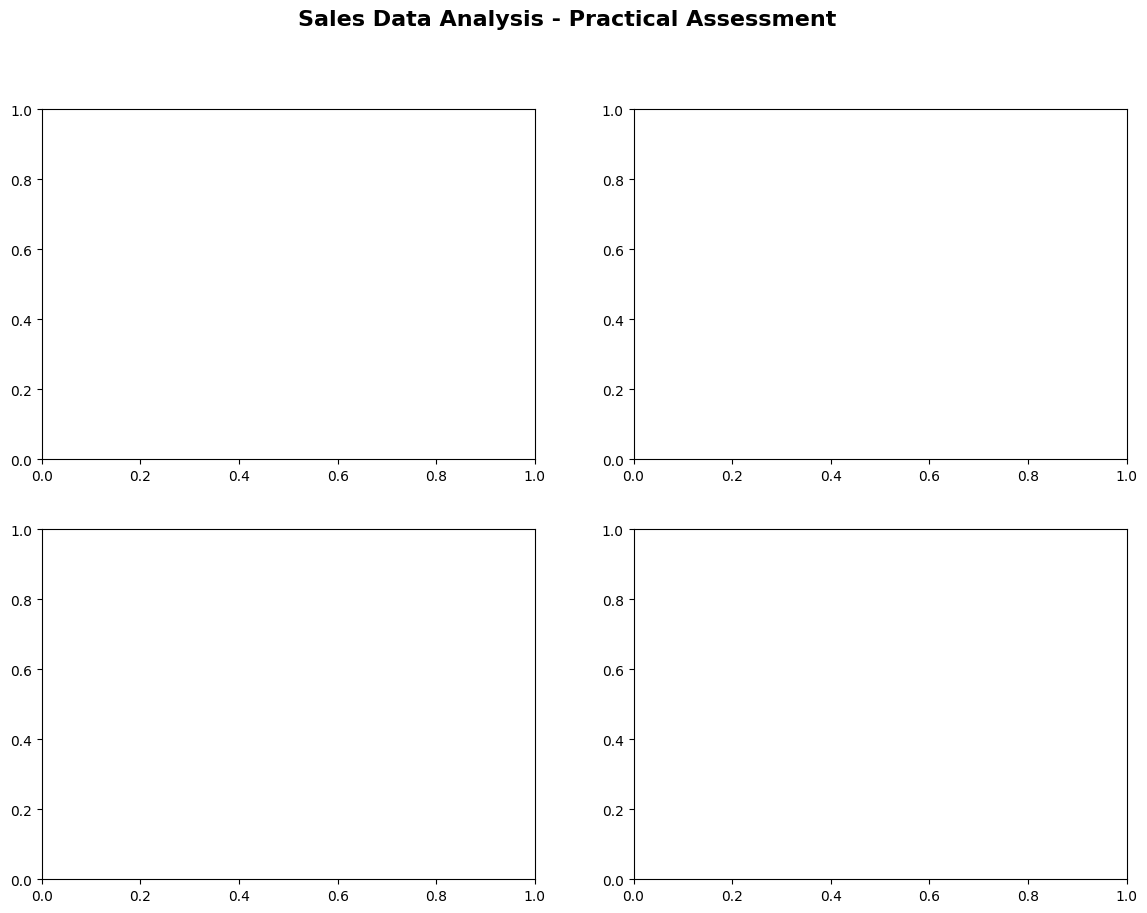

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Data Analysis - Practical Assessment', fontsize=16, fontweight='bold')


In [ ]:
axes[0, 0].plot(df['Date'], df['Total_Sales'], marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0, 0].set_title('Total Sales Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date', fontsize=10)
axes[0, 0].set_ylabel('Total Sales ($)', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45

SyntaxError: incomplete input (ipython-input-2391968606.py, line 6)

In [ ]:
products = total_sales_by_product.index
sales = total_sales_by_product.values
colors = ['#A23B72', '#F18F01', '#C73E1D']
axes[0, 1].bar(products, sales, color=colors, edgecolor='black', linewidth=1.2)
axes[0, 1].set_title('Total Sales by Product', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Product', fontsize=10)
axes[0, 1].set_ylabel('Total Sales ($)', fontsize=10)
axes[0, 1].grid(True, axis='y', alpha=0.3)

In [ ]:
for i, v in enumerate(sales):
    axes[0, 1].text(i, v + 200, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')


In [ ]:
scatter = axes[1, 0].scatter(df['Units_Sold'], df['Unit_Price'],
                             c=df['Total_Sales'], cmap='viridis',
                             s=100, alpha=0.7, edgecolors='black', linewidth=1)
axes[1, 0].set_title('Units Sold vs Unit Price', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Units Sold', fontsize=10)
axes[1, 0].set_ylabel('Unit Price ($)', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

In [ ]:
cbar = plt.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Total Sales ($)', rotation=270, labelpad=15)


/tmp/ipython-input-1457022779.py:1: UserWarning: Adding colorbar to a different Figure <Figure size 1400x1000 with 5 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(scatter, ax=axes[1, 0])


<Figure size 640x480 with 0 Axes>

In [ ]:
axes[1, 1].axis('off')
summary_text = f"""
SUMMARY STATISTICS

Total Revenue: ${df['Total_Sales'].sum():,.0f}

By Product:
  Product A: ${total_sales_by_product['A']:,.0f}
  Product B: ${total_sales_by_product['B']:,.0f}
  Product C: ${total_sales_by_product['C']:,.0f}

Average Units by Region:
  East: {avg_units_by_region['East']:.1f}
  North: {avg_units_by_region['North']:.1f}
  South: {avg_units_by_region['South']:.1f}
  West: {avg_units_by_region['West']:.1f}

Best Selling Day:
  {top_3_days.iloc[0]['Date'].strftime('%Y-%m-%d')}
  Total: ${top_3_days.iloc[0]['Total_Sales']:,.0f}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round',
                facecolor='wheat', alpha=0.3))
axes[1, 1].set_title('Summary Report', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>